In [33]:
import pandas as pd
import numpy as np
import xlrd
import re
import matplotlib.pyplot as plt

In [2]:
raw_df = pd.read_excel("../data/GSAF5.xls")
raw_df

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,14th October,2025.0,Unprovoked,Columbia,"Bolivar, del Isolate",Catagena Province,Swimming with sharks,Male child,M,14,...,Nurse shark,Kevin McMurray Trackingsharks.com Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11th October,2025.0,Unprovoked,Australia,Queensland,Cook Esplanade Thursday Island,Fishing/swimming,Samuel Nai,M,14,...,Tiger or Bull shark,Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7th October,2025.0,Unprovoked,Australia,South Australia,Kangaroo Island,Surfing,Lee Berryman,M,50+,...,Bronze whaler?,Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,29th September,2025.0,Unprovoked,USA,Off California,Catalina Island,Swimming,Christopher Murray,M,54,...,unknown 1.2m shark,Todd Smith: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,27th September,2025.0,Provoked,Costa Rica,NaN,Cocos Islands,Diving-Tagging sharks,Dr. Mauricio Hoyos,M,48,...,Tiger shark 4m,Todd Smith: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN
7046,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN
7047,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN
7048,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN


In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7050 non-null   object 
 1   Year            7048 non-null   float64
 2   Type            7032 non-null   object 
 3   Country         7000 non-null   object 
 4   State           6564 non-null   object 
 5   Location        6483 non-null   object 
 6   Activity        6465 non-null   object 
 7   Name            6831 non-null   object 
 8   Sex             6471 non-null   object 
 9   Age             4056 non-null   object 
 10  Injury          7015 non-null   object 
 11  Fatal Y/N       6489 non-null   object 
 12  Time            3524 non-null   object 
 13  Species         3919 non-null   object 
 14  Source          7030 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

In [4]:
raw_df.isnull().sum()

Date                 0
Year                 2
Type                18
Country             50
State              486
Location           567
Activity           585
Name               219
Sex                579
Age               2994
Injury              35
Fatal Y/N          561
Time              3526
Species           3131
Source              20
pdf                251
href formula       256
href               254
Case Number        252
Case Number.1      253
original order     251
Unnamed: 21       7049
Unnamed: 22       7048
dtype: int64

In [5]:
raw_df.dropna().sum()

Date                0
Year              0.0
Type                0
Country             0
State               0
Location            0
Activity            0
Name                0
Sex                 0
Age                 0
Injury              0
Fatal Y/N           0
Time                0
Species             0
Source              0
pdf                 0
href formula        0
href                0
Case Number         0
Case Number.1       0
original order    0.0
Unnamed: 21         0
Unnamed: 22         0
dtype: object

# Drop Columns

In [6]:
final_df = raw_df.drop(['pdf', 'href formula', 'href', 'Unnamed: 21', 'Unnamed: 22'], axis = 1)
final_df

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,Case Number.1,original order
0,14th October,2025.0,Unprovoked,Columbia,"Bolivar, del Isolate",Catagena Province,Swimming with sharks,Male child,M,14,Severe hand injury,N,Not stated,Nurse shark,Kevin McMurray Trackingsharks.com Andy Currie,NaN,NaN,NaN
1,11th October,2025.0,Unprovoked,Australia,Queensland,Cook Esplanade Thursday Island,Fishing/swimming,Samuel Nai,M,14,Serious abdonminal injuries,N,1823 hrs,Tiger or Bull shark,Kevin McMurray Trackingsharks.com,NaN,NaN,NaN
2,7th October,2025.0,Unprovoked,Australia,South Australia,Kangaroo Island,Surfing,Lee Berryman,M,50+,Lacerations to calf,N,1330hrs,Bronze whaler?,Kevin McMurray Trackingsharks.com,NaN,NaN,NaN
3,29th September,2025.0,Unprovoked,USA,Off California,Catalina Island,Swimming,Christopher Murray,M,54,Leg and foot injury,N,0100hrs,unknown 1.2m shark,Todd Smith: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN
4,27th September,2025.0,Provoked,Costa Rica,NaN,Cocos Islands,Diving-Tagging sharks,Dr. Mauricio Hoyos,M,48,Head face and arms,N,Not stated,Tiger shark 4m,Todd Smith: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, p. 234",ND.0005,ND.0005,6.0
7046,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,ND.0004,5.0
7047,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,ND.0003,4.0
7048,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN,"The Sun, 10/20/1938",ND.0002,ND.0002,3.0


# Standardize Column Names

In [7]:
final_df.columns = final_df.columns.str.strip().str.upper().str.replace(" ", "_")
final_df.columns

Index(['DATE', 'YEAR', 'TYPE', 'COUNTRY', 'STATE', 'LOCATION', 'ACTIVITY',
       'NAME', 'SEX', 'AGE', 'INJURY', 'FATAL_Y/N', 'TIME', 'SPECIES',
       'SOURCE', 'CASE_NUMBER', 'CASE_NUMBER.1', 'ORIGINAL_ORDER'],
      dtype='object')

# Handle Missing Values

In [8]:
final_df.replace("?", np.nan, inplace=True)

# Clean the Age Column

In [9]:
final_df["AGE"] = final_df["AGE"].astype(str).str.lower().str.strip()

final_df['AGE_CLEANED'] = final_df['AGE'].str.extract('(\d+)')
final_df['AGE_CLEANED'] = pd.to_numeric(final_df['AGE_CLEANED'], errors='coerce')

# Clean the Sex Column

In [27]:
final_df['SEX'] = final_df['SEX'].str.strip()

final_df['SEX'] = final_df['SEX'].replace({
    'm': 'Male',
    'f': 'Female'
})

# Clean the Fatal Column

In [53]:
final_df['FATAL_Y/N'] = final_df['FATAL_Y/N'].str.upper().str.strip()

final_df['FATAL_Y/N'] = final_df['FATAL_Y/N'].replace({
    'Y': 'Yes',
    'N': 'No'
})

In [58]:
if "FATAL_Y/N" in final_df.columns:
    final_df["FATAL"] = final_df["FATAL_Y/N"].astype(str).str.upper().str.strip()
else:
    final_df["FATAL"] = np.nan

# Convert Data Types

In [12]:
final_df['YEAR'] = pd.to_numeric(final_df['YEAR'], errors='coerce')

# Clean Text Columns

In [13]:
final_df['COUNTRY'] = final_df['COUNTRY'].str.strip()
final_df['ACTIVITY'] = final_df['ACTIVITY'].str.strip()

# Clean Activity Column

## Inspect Unique Values

In [14]:
final_df['ACTIVITY'].value_counts().head(20)

ACTIVITY
Surfing            1145
Swimming           1052
Fishing             509
Spearfishing        399
Wading              178
Bathing             167
Diving              151
Snorkeling          133
Standing            115
Scuba diving         85
Body boarding        64
Body surfing         51
Kayaking             43
Boogie boarding      42
Free diving          35
Treading water       33
Fell overboard       33
Pearl diving         32
Surf skiing          24
Windsurfing          20
Name: count, dtype: int64

## Remove Extra Spaces & Convert to Lowercase

In [15]:
final_df['ACTIVITY'] = final_df['ACTIVITY'].str.lower().str.strip()

## Handle Missing Values

In [16]:
final_df['ACTIVITY'] = final_df['ACTIVITY'].replace(['?', 'unknown', 'n/a'], np.nan)

## Group Similar Activities

In [17]:
def clean_activity(activity):

    if pd.isna(activity):
        return np.nan

    activity = activity.lower()

    if 'surf' in activity:
        return 'Surfing'

    elif 'swim' in activity or 'bathing' in activity or 'wading' in activity:
        return 'Swimming'

    elif 'fish' in activity:
        return 'Fishing'

    elif 'dive' in activity or 'scuba' in activity:
        return 'Diving'

    elif 'boat' in activity or 'kayak' in activity or 'canoe' in activity:
        return 'Boating'

    else:
        return 'Other'

In [18]:
final_df['ACTIVITY_CLEANED'] = final_df['ACTIVITY'].apply(clean_activity)

In [19]:
final_df['ACTIVITY_CLEANED'].value_counts()

ACTIVITY_CLEANED
Other       1751
Swimming    1643
Surfing     1453
Fishing     1303
Boating      168
Diving       144
Name: count, dtype: int64

# Clean TYPE Column

In [20]:
final_df["TYPE"] = final_df["TYPE"].str.strip().str.lower()

In [21]:
def simple_type(s):
    
    if s == "unprovoked":
        return "Unprovoked"
    elif s == "provoked":
        return "Provoked"
    else:
        return "Other"

In [22]:
final_df["TYPE_CLEANED"] = final_df["TYPE"].apply(simple_type)

# Final Dataframe & CSV

In [59]:
final_df

,DATE,YEAR,TYPE,COUNTRY,STATE,LOCATION,ACTIVITY,NAME,SEX,AGE,...,TIME,SPECIES,SOURCE,CASE_NUMBER,CASE_NUMBER.1,ORIGINAL_ORDER,AGE_CLEANED,ACTIVITY_CLEANED,TYPE_CLEANED,FATAL
0,14th October,2025.0,unprovoked,Columbia,"Bolivar, del Isolate",Catagena Province,swimming with sharks,Male child,Male,14,...,Not stated,Nurse shark,Kevin McMurray Trackingsharks.com Andy Currie,NaN,NaN,NaN,14.0,Swimming,Unprovoked,NO
1,11th October,2025.0,unprovoked,Australia,Queensland,Cook Esplanade Thursday Island,fishing/swimming,Samuel Nai,Male,14,...,1823 hrs,Tiger or Bull shark,Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,14.0,Swimming,Unprovoked,NO
2,7th October,2025.0,unprovoked,Australia,South Australia,Kangaroo Island,surfing,Lee Berryman,Male,50+,...,1330hrs,Bronze whaler?,Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,50.0,Surfing,Unprovoked,NO
3,29th September,2025.0,unprovoked,USA,Off California,Catalina Island,swimming,Christopher Murray,Male,54,...,0100hrs,unknown 1.2m shark,Todd Smith: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,54.0,Swimming,Unprovoked,NO
4,27th September,2025.0,provoked,Costa Rica,NaN,Cocos Islands,diving-tagging sharks,Dr. Mauricio Hoyos,Male,48,...,Not stated,Tiger shark 4m,Todd Smith: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,48.0,Other,Provoked,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,Before 1903,0.0,unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,diving,male,Male,nan,...,NaN,NaN,"H. Taunton; N. Bartlett, p. 234",ND.0005,ND.0005,6.0,NaN,Other,Unprovoked,YES
7046,Before 1903,0.0,unprovoked,AUSTRALIA,Western Australia,NaN,pearl diving,Ahmun,Male,nan,...,NaN,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,ND.0004,5.0,NaN,Other,Unprovoked,YES
7047,1900-1905,0.0,unprovoked,USA,North Carolina,Ocracoke Inlet,swimming,Coast Guard personnel,Male,nan,...,NaN,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,ND.0003,4.0,NaN,Swimming,Unprovoked,YES
7048,1883-1889,0.0,unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,Male,nan,...,NaN,NaN,"The Sun, 10/20/1938",ND.0002,ND.0002,3.0,NaN,NaN,Unprovoked,YES


In [68]:
final_df.columns

Index(['DATE', 'YEAR', 'TYPE', 'COUNTRY', 'STATE', 'LOCATION', 'ACTIVITY',
       'NAME', 'SEX', 'AGE', 'INJURY', 'FATAL_Y/N', 'TIME', 'SPECIES',
       'SOURCE', 'CASE_NUMBER', 'CASE_NUMBER.1', 'ORIGINAL_ORDER',
       'AGE_CLEANED', 'ACTIVITY_CLEANED', 'TYPE_CLEANED', 'FATAL'],
      dtype='object')

In [29]:
final_df.to_csv("shark_attacks.csv", index=False, sep=";", encoding="utf-8")

# EDA

### Top countries with shark attacks

In [31]:
top_countries = final_df["COUNTRY"].value_counts().head(10)
top_countries

COUNTRY
USA                 2573
AUSTRALIA           1481
SOUTH AFRICA         597
NEW ZEALAND          144
BAHAMAS              136
PAPUA NEW GUINEA     136
BRAZIL               122
MEXICO               104
ITALY                 72
FIJI                  67
Name: count, dtype: int64

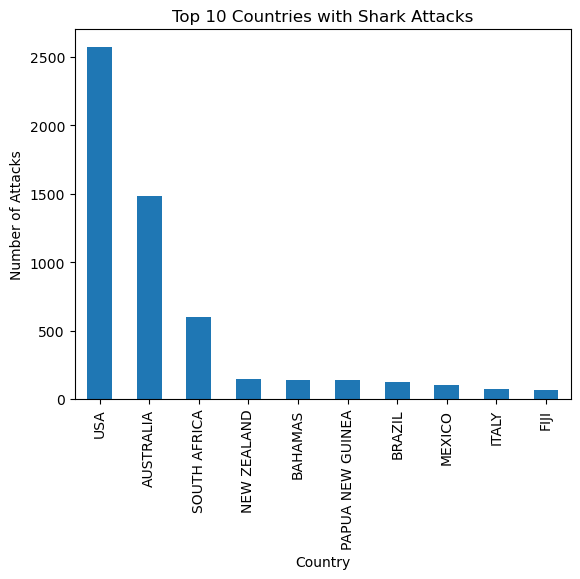

In [34]:
plt.figure()
top_countries.plot(kind="bar")
plt.title("Top 10 Countries with Shark Attacks")
plt.xlabel("Country")
plt.ylabel("Number of Attacks")
plt.show()

### Top activities during shark attacks

In [36]:
top_activities = final_df["ACTIVITY"].value_counts().head(10)
top_activities

ACTIVITY
surfing         1145
swimming        1052
fishing          509
spearfishing     399
wading           178
bathing          167
diving           151
snorkeling       134
standing         115
scuba diving     104
Name: count, dtype: int64

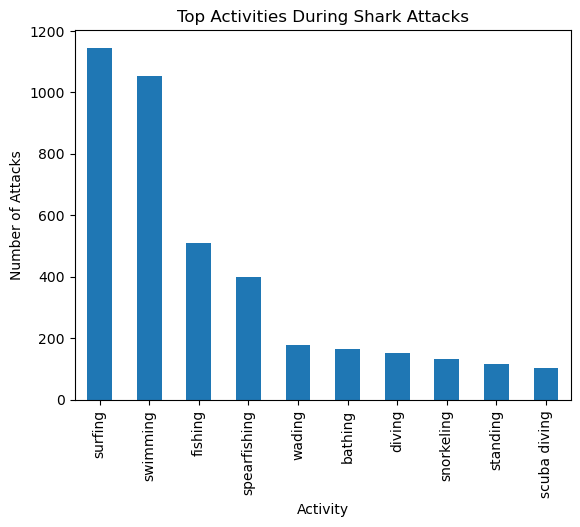

In [37]:
plt.figure()
top_activities.plot(kind="bar")
plt.title("Top Activities During Shark Attacks")
plt.xlabel("Activity")
plt.ylabel("Number of Attacks")
plt.show()

### Shark attacks by year

In [38]:
attacks_by_year = final_df["YEAR"].value_counts().sort_index()
attacks_by_year

YEAR
0.0       129
5.0         1
77.0        1
1000.0      1
1500.0      1
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     56
2026.0      1
Name: count, Length: 261, dtype: int64

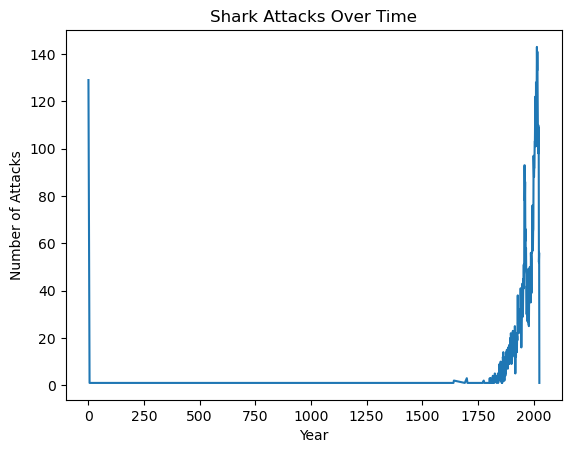

In [42]:
plt.figure()
attacks_by_year.plot()
plt.title("Shark Attacks Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.show()

### Age distribution

In [47]:
age_stats = final_df["AGE_CLEANED"].describe()
age_stats

count    4011.000000
mean       28.137871
std        14.661932
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: AGE_CLEANED, dtype: float64

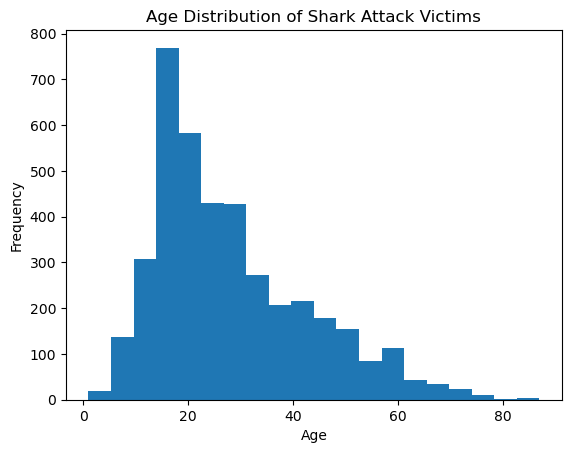

In [45]:
plt.figure()
final_df["AGE_CLEANED"].dropna().plot(kind="hist", bins=20)
plt.title("Age Distribution of Shark Attack Victims")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Fatal Counts

In [61]:
fatal_counts = final_df["FATAL"].value_counts()
fatal_counts

FATAL
NO         4924
YES        1483
NAN         562
UNKNOWN      71
F             5
M             3
NQ            1
Y X 2         1
Name: count, dtype: int64

### Sex Counts

In [62]:
sex_counts = final_df["SEX"].value_counts()
sex_counts

SEX
Male      5659
Female     807
n            2
lli          1
m x 2        1
.            1
Name: count, dtype: int64

## Fatality Rate By Activity

In [66]:
# Keep only valid values
final_df = final_df[final_df['FATAL'].isin(['YES','NO'])]

# Group by activity
fatality_activity = final_df.groupby('ACTIVITY_CLEANED').agg(
    total_attacks=('FATAL','count'),
    fatal_attacks=('FATAL', lambda x: (x=='Y').sum())
)

# Calculate fatality rate
fatality_activity['fatality_rate_%'] = (
    fatality_activity['fatal_attacks'] /
    fatality_activity['total_attacks']
) * 100

# Sort by fatality rate
fatality_activity = fatality_activity.sort_values(
    by='fatality_rate_%', ascending=False
)

fatality_activity.head(10)

,total_attacks,fatal_attacks,fatality_rate_%
ACTIVITY_CLEANED,,,
Boating,145,0,0.0
Diving,119,0,0.0
Fishing,1220,0,0.0
Other,1609,0,0.0
Surfing,1396,0,0.0
Swimming,1497,0,0.0


In [71]:
summary_activity = pd.DataFrame({
    "Total": final_df["ACTIVITY_CLEANED"].value_counts(),
    "Fatal": final_df[final_df["FATAL"] == "YES"]["ACTIVITY_CLEANED"].value_counts()
})

summary_activity["fatality_rate_%"] = (summary_activity["Fatal"] / summary_activity["Total"] * 100).round(2)
summary_activity.sort_values("fatality_rate_%", ascending=False)

,Total,Fatal,fatality_rate_%
ACTIVITY_CLEANED,,,
Boating,145,53,36.55
Swimming,1497,541,36.14
Other,1609,474,29.46
Diving,119,33,27.73
Fishing,1220,179,14.67
Surfing,1396,93,6.66


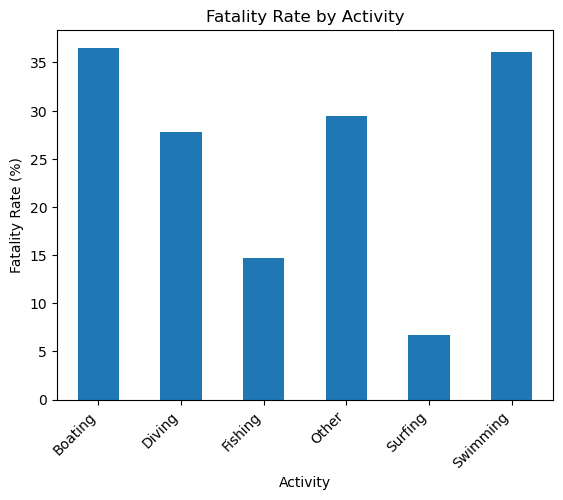

In [74]:
summary_activity['fatality_rate_%'].plot(kind='bar')
plt.title('Fatality Rate by Activity')
plt.xlabel('Activity')
plt.ylabel('Fatality Rate (%)')
plt.xticks(rotation=45, ha="right")
plt.show()

## Top 5 Activities During Attacks

In [77]:
activity_fatal_counts = final_df["ACTIVITY_CLEANED"].value_counts()
activity_fatal_counts = activity_fatal_counts.drop("Other", errors="ignore")
activity_fatal_counts = activity_fatal_counts.drop("Unknown", errors="ignore")
activity_fatal_counts

ACTIVITY_CLEANED
Swimming    1497
Surfing     1396
Fishing     1220
Boating      145
Diving       119
Name: count, dtype: int64

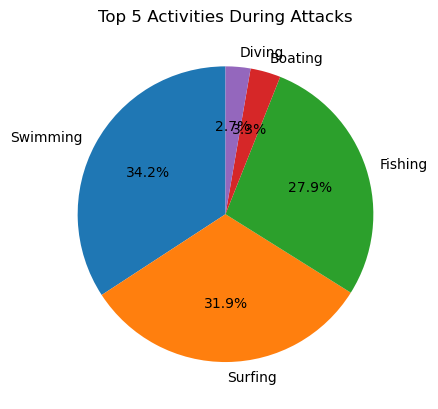

In [81]:
plt.figure()
activity_fatal_counts.head(5).plot(kind="pie", autopct='%1.1f%%', startangle=90)
plt.title("Top 5 Activities During Attacks")
plt.ylabel("")
plt.show()

## Top 5 Activities During Fatal Attacks

In [82]:
fatal_df = final_df[final_df["FATAL"]=="YES"]
activity_fatal_counts = fatal_df["ACTIVITY_CLEANED"].value_counts()
activity_fatal_counts = activity_fatal_counts.drop("Other", errors="ignore")
activity_fatal_counts = activity_fatal_counts.drop("Unknown", errors="ignore")
activity_fatal_counts

ACTIVITY_CLEANED
Swimming    541
Fishing     179
Surfing      93
Boating      53
Diving       33
Name: count, dtype: int64

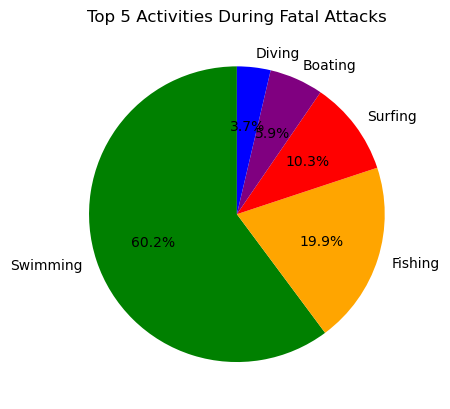

In [83]:
plt.figure()
activity_fatal_counts.head(5).plot(kind="pie", autopct='%1.1f%%', startangle=90,
                                  colors=["green", "orange", "red", "purple", "blue"])
plt.title("Top 5 Activities During Fatal Attacks")
plt.ylabel("")
plt.show()